[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/06_end_to_end_projects/multimodal/multimodal.ipynb)


# 05 . Multimodal: CLIP-style Contrastive Image-Text Learning

## Concept — CLIP-style contrastive dual encoder (revision notes)

**What it is**
- Two encoders (one for images, one for text) map their inputs into the SAME vector space.
  Training pulls each image towards its own caption and pushes it away from the other captions in the batch.
- No class labels are needed - the caption is the supervision. Afterwards you can search images with text,
  captions with images, or classify by comparing an image to text prompts ("zero-shot").

**Why it matters**
- It is the backbone of image search, text-to-image models' text conditioning and many multimodal LLMs.
- The symmetric loss, the temperature and the batch construction decide whether it works at all.

**When to use**
- You have paired data (image, text) but not fixed labels, or want open-vocabulary classification/retrieval.
- Not suited when you need fine-grained spatial reasoning or exact counting: the embedding is one global vector.

**Math & intuition**
- Embeddings are L2-normalised, so `<image, text>` is cosine similarity. For a batch of B pairs the logit matrix is
  `S = scale * I T^T` (B x B); the diagonal holds the true pairs.
- Loss = average of cross-entropy over rows (image -> which caption?) and over columns (text -> which image?), target = diagonal.
  For a random model with scale 1 it is about `ln B`.
- `scale = exp(logit_scale)` is a learnable inverse temperature (starts at 1/0.07 ~ 14.3). Large scale = sharper softmax.
- Duplicates: two pairs with the same concept in one batch make a false negative; we mask them.

### 1. Setup and imports

**What this cell does (plain language):** makes the project folder importable, imports data/model/train code and seeds the RNG.

In [1]:
import os, sys, subprocess
# The notebook imports a small tested module that lives next to it.
# On Colab that folder is not there yet, so fetch the repo once and move into the project directory.
PROJECT = "06_end_to_end_projects/multimodal"
if not os.path.exists("data.py"):
    if not os.path.exists("PyTorch-Mastery"):
        subprocess.run(["git", "clone", "-q", "https://github.com/himanshu231204/PyTorch-Mastery"], check=False)
    if os.path.isdir("PyTorch-Mastery/" + PROJECT):
        os.chdir("PyTorch-Mastery/" + PROJECT)
sys.path.insert(0, os.getcwd())

import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from data import make_pairs, Tokenizer, CONCEPTS, HELD_OUT
from model import CLIP, ImageEncoder, TextEncoder
from train import clip_loss, fit, retrieval_metrics, zero_shot_classify

torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.1+cu130


### 2. Synthetic image-caption pairs

**What this cell does (plain language):** generates 16x16 RGB images of one coloured shape (4 colours x 4 shapes = 16 concepts) on a dark noisy background, each paired with a caption from four templates (`a red circle`, `circle in red`, `the circle is red`, `photo of a red circle`). Different wordings of the same meaning force the text encoder to learn semantics rather than memorise strings.

images: (800, 3, 16, 16) | captions: 800 | concepts: 16


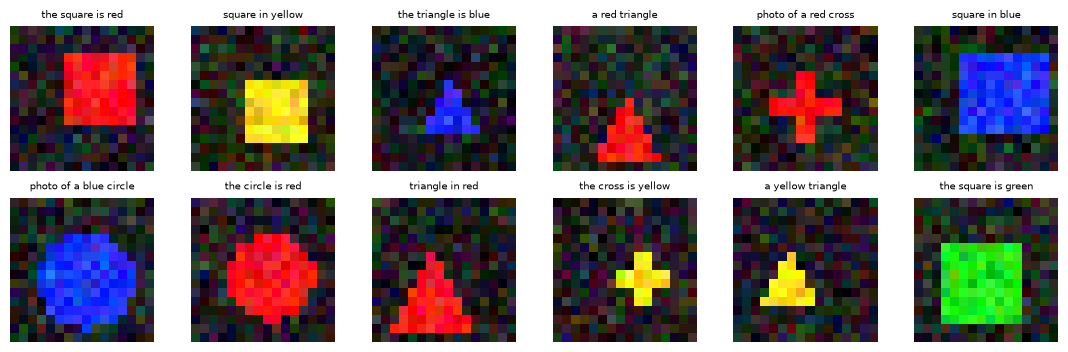

In [2]:
images, captions, concept = make_pairs(800, seed=0)
print("images:", tuple(images.shape), "| captions:", len(captions), "| concepts:", len(CONCEPTS))
fig, axes = plt.subplots(2, 6, figsize=(11, 3.6))
for ax, img, cap in zip(axes.flat, images[:12], captions[:12]):
    ax.imshow(img.permute(1, 2, 0)); ax.set_title(cap, fontsize=7); ax.axis("off")
plt.tight_layout(); plt.show()

### 3. Split: seen concepts for training, three unseen combinations held out

**What this cell does (plain language):** we remove three colour+shape combinations (`blue cross`, `yellow triangle`, `green square`) from training entirely. Their colour and their shape each still appear in other combinations, so after training we can ask whether the model composes known words and visuals into a new concept. We also build the tokenizer (a closed vocabulary) and check no caption word is unknown.

In [3]:
seen = [c for c in CONCEPTS if c not in HELD_OUT]
tr_img, tr_cap, tr_c = make_pairs(800, concepts=seen, seed=0)
va_img, va_cap, va_c = make_pairs(260, concepts=seen, seed=1)          # new images, same concepts
ho_img, ho_cap, ho_c = make_pairs(130, concepts=HELD_OUT, seed=2)      # unseen concepts
tok = Tokenizer()
print("train/val/held-out sizes:", len(tr_img), len(va_img), len(ho_img), "| held out:", HELD_OUT)
print("vocab:", tok.itos)
print("unknown tokens in train captions:", int((tok.batch(tr_cap) == 1).sum()))
print("example ids:", tr_cap[0], "->", tok.batch([tr_cap[0]])[0].tolist())

train/val/held-out sizes: 800 260 130 | held out: [('blue', 'cross'), ('yellow', 'triangle'), ('green', 'square')]
vocab: ['<pad>', '<unk>', 'a', 'blue', 'circle', 'cross', 'green', 'in', 'is', 'of', 'photo', 'red', 'square', 'the', 'triangle', 'yellow']
unknown tokens in train captions: 0
example ids: the square is blue -> [13, 12, 8, 3, 0, 0]


### 4. The two encoders and the shared space

**What this cell does (plain language):** builds the image CNN and the text transformer and sends one batch through each. Both outputs have the same dimension (32) and after L2-normalisation lie on the unit sphere, which is what makes image and text vectors comparable. We print shapes and norms.

In [4]:
torch.manual_seed(0)
model = CLIP(len(tok), dim=32)
ie, te, scale = model(tr_img[:4], tok.batch(tr_cap[:4]))
print("image embeddings:", tuple(ie.shape), "norms:", [round(v, 3) for v in ie.norm(dim=-1).tolist()])
print("text  embeddings:", tuple(te.shape), "norms:", [round(v, 3) for v in te.norm(dim=-1).tolist()])
print("initial logit scale:", round(scale.item(), 2), "(= 1/0.07)")
print("image encoder params:", sum(p.numel() for p in model.image.parameters()),
      "| text encoder params:", sum(p.numel() for p in model.text.parameters()))

image embeddings: (4, 32) norms: [1.0, 1.0, 1.0, 1.0]
text  embeddings: (4, 32) norms: [1.0, 1.0, 1.0, 1.0]
initial logit scale: 14.29 (= 1/0.07)
image encoder params: 15488 | text encoder params: 10304


### 5. The contrastive loss by hand

**What this cell does (plain language):** computes the B x B similarity matrix and the symmetric loss from scratch and checks it equals our `clip_loss`. Then we test two extremes: with identical, well-separated embeddings the loss is near zero; with random embeddings and scale 1 it sits near `ln B`. If your untrained loss is far from `ln B`, suspect a bug in normalisation or scale.

In [5]:
B = 8
a = F.normalize(torch.randn(B, 32), dim=-1); b = F.normalize(torch.randn(B, 32), dim=-1)
logits = 1.0 * a @ b.T
manual = (F.cross_entropy(logits, torch.arange(B)) + F.cross_entropy(logits.T, torch.arange(B))) / 2
print("manual == clip_loss:", torch.allclose(manual, clip_loss(a, b, 1.0)))
print(f"random embeddings, scale 1: {clip_loss(a, b, 1.0):.3f} (ln {B} = {torch.log(torch.tensor(float(B))):.3f})")
print(f"perfectly aligned, scale 50: {clip_loss(a, a.clone(), 50.0):.5f}")

manual == clip_loss: True
random embeddings, scale 1: 2.153 (ln 8 = 2.079)
perfectly aligned, scale 50: 0.00000


### 6. False negatives: duplicate concepts in a batch

**What this cell does (plain language):** with only 13 training concepts, a batch of 64 has many pairs with the SAME concept, e.g. several `red circle` images. Treating those as negatives asks the model to separate identical meanings - impossible - and hurts learning. We show how many same-concept off-diagonal pairs a random batch contains and mask them via the `group` argument.

In [6]:
g = torch.Generator().manual_seed(0)
idx = torch.randperm(len(tr_img), generator=g)[:64]
same = tr_c[idx][:, None] == tr_c[idx][None, :]
same.fill_diagonal_(False)
print("same-concept off-diagonal pairs in a batch of 64:", int(same.sum()), "of", 64 * 63)
ie, te, s = model(tr_img[idx], tok.batch([tr_cap[i] for i in idx.tolist()]))
print(f"loss without mask {clip_loss(ie, te, s):.3f} | with mask {clip_loss(ie, te, s, tr_c[idx]):.3f}")

same-concept off-diagonal pairs in a batch of 64: 318 of 4032
loss without mask 4.791 | with mask 4.704


### 7. Train the dual encoder

**What this cell does (plain language):** trains both encoders (and the temperature) jointly for 20 epochs with AdamW and batch size 64. The loss should fall from about `ln 64` (4.2) towards zero; the logit scale rises as the model becomes more confident.

epoch  1 | loss 3.850 | logit scale 14.1
epoch  2 | loss 2.630 | logit scale 14.2


epoch  3 | loss 2.310 | logit scale 14.3
epoch  4 | loss 1.978 | logit scale 14.5


epoch  5 | loss 1.792 | logit scale 14.6
epoch  6 | loss 1.389 | logit scale 14.9


epoch  7 | loss 1.122 | logit scale 15.3
epoch  8 | loss 0.682 | logit scale 16.0


epoch  9 | loss 0.544 | logit scale 16.6
epoch 10 | loss 0.320 | logit scale 17.2


epoch 11 | loss 0.318 | logit scale 17.7
epoch 12 | loss 0.250 | logit scale 18.2


epoch 13 | loss 0.080 | logit scale 18.6
epoch 14 | loss 0.063 | logit scale 19.0


epoch 15 | loss 0.103 | logit scale 19.2
epoch 16 | loss 0.096 | logit scale 19.4


epoch 17 | loss 0.046 | logit scale 19.7
epoch 18 | loss 0.032 | logit scale 19.9


epoch 19 | loss 0.028 | logit scale 20.1
epoch 20 | loss 0.022 | logit scale 20.2


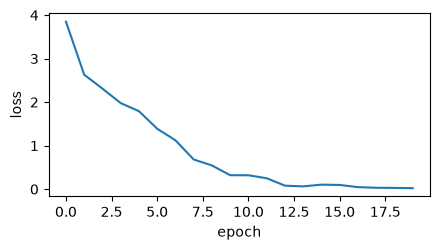

In [7]:
torch.manual_seed(0)
model = CLIP(len(tok), dim=32)
hist = fit(model, tok, tr_img, tr_cap, tr_c, epochs=20, bs=64, lr=3e-3, seed=0)
plt.figure(figsize=(4.5, 2.6)); plt.plot(hist); plt.xlabel("epoch"); plt.ylabel("loss"); plt.tight_layout(); plt.show()

### 8. Retrieval evaluation on new images of seen concepts

**What this cell does (plain language):** scores held-out validation images and captions. Because many images share a concept, we define correctness at concept level: image-to-text ranks one canonical caption per concept (R@1, R@3), and text-to-image reports precision of the top-5 retrieved images. Exact-index matching would wrongly mark correct answers as misses.

In [8]:
metrics = retrieval_metrics(model, tok, va_img, va_cap, va_c)
for k, v in metrics.items():
    print(f"{k:9s} {v:.3f}")
print("chance for i2t_R@1 with", len(seen), "concepts:", round(1 / len(seen), 3))

i2t_R@1   0.969
i2t_R@3   1.000
t2i_P@5   1.000
chance for i2t_R@1 with 13 concepts: 0.077


### 9. Look at text-to-image search

**What this cell does (plain language):** takes a text query, ranks all 260 validation images by cosine similarity and shows the top 6 with their true concept. A visual check often reveals subtle errors (e.g. always confusing two shapes) that aggregate numbers hide.

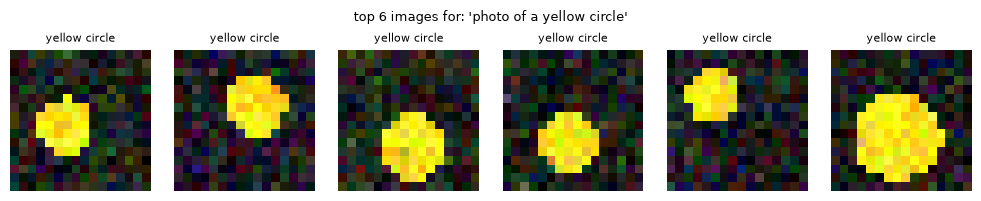

In [9]:
query = "photo of a yellow circle"
with torch.no_grad():
    sims = model.encode_image(va_img) @ model.encode_text(tok.batch([query])).T
top = sims[:, 0].topk(6).indices
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, i in zip(axes, top.tolist()):
    ax.imshow(va_img[i].permute(1, 2, 0)); ax.axis("off"); ax.set_title(" ".join(CONCEPTS[va_c[i]]), fontsize=8)
plt.suptitle(f"top 6 images for: {query!r}", fontsize=9); plt.tight_layout(); plt.show()

### 10. Zero-shot classification, including unseen combinations

**What this cell does (plain language):** classifies images by comparing them with text prompts for all 16 concepts - no classifier head. On seen concepts this should be accurate. For the three held-out combinations the model never saw a matching image+caption, so we measure how often it gets the colour right, the shape right and both right. This tests compositional generalisation, which small contrastive models are known to find hard.

In [10]:
prompts = [f"a {c} {s}" for c, s in CONCEPTS]
def zs(images, concept):
    p = zero_shot_classify(model, tok, images, prompts)
    both = (p == concept).float().mean().item()
    col = torch.tensor([CONCEPTS[a][0] == CONCEPTS[b][0] for a, b in zip(p.tolist(), concept.tolist())]).float().mean().item()
    shp = torch.tensor([CONCEPTS[a][1] == CONCEPTS[b][1] for a, b in zip(p.tolist(), concept.tolist())]).float().mean().item()
    return both, col, shp
for name, (im, c) in (("seen concepts", (va_img, va_c)), ("held-out concepts", (ho_img, ho_c))):
    both, col, shp = zs(im, c)
    print(f"{name:18s} both right {both:.3f} | colour right {col:.3f} | shape right {shp:.3f}")
print("chance (16 prompts):", 1 / 16)

seen concepts      both right 0.969 | colour right 0.996 | shape right 0.969
held-out concepts  both right 0.331 | colour right 1.000 | shape right 0.331
chance (16 prompts): 0.0625


### 11. Ablation: what does masking duplicates buy us?

**What this cell does (plain language):** retrains the same model with `mask_dups=False` for the same 20 epochs and compares retrieval. If the difference is small on this easy task that is a finding too - report what you measure, then try a smaller batch or a harder task before drawing conclusions.

In [11]:
torch.manual_seed(0)
m_nomask = CLIP(len(tok), dim=32)
fit(m_nomask, tok, tr_img, tr_cap, tr_c, epochs=20, bs=64, lr=3e-3, seed=0, mask_dups=False, verbose=False)
for name, m in (("masked duplicates", model), ("no mask", m_nomask)):
    r = retrieval_metrics(m, tok, va_img, va_cap, va_c)
    print(f"{name:18s}", {k: round(v, 3) for k, v in r.items()})

masked duplicates  {'i2t_R@1': 0.969, 'i2t_R@3': 1.0, 't2i_P@5': 1.0}
no mask            {'i2t_R@1': 0.942, 'i2t_R@3': 1.0, 't2i_P@5': 0.968}


### 12. Visualise the shared embedding space

**What this cell does (plain language):** projects image and text embeddings to 2D with PCA (via `torch.pca_lowrank`) and plots them together. If the contrastive training worked, each concept's images cluster and the matching canonical caption sits near that cluster - one space for both modalities.

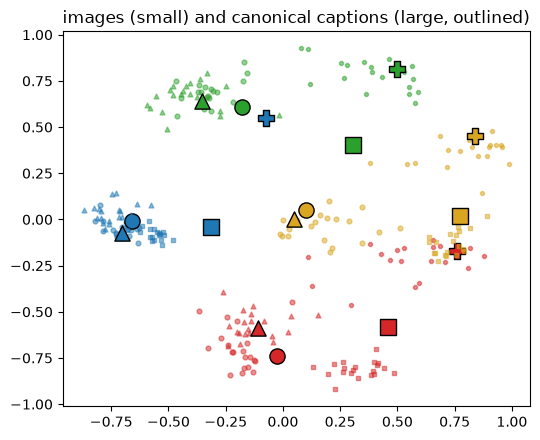

In [12]:
with torch.no_grad():
    ie_all = model.encode_image(va_img)
    te_all = model.encode_text(tok.batch([f"a {c} {s}" for c, s in CONCEPTS]))
both = torch.cat([ie_all, te_all]); mu = both.mean(0)
_, _, V = torch.pca_lowrank(both - mu, q=2)
P = (both - mu) @ V[:, :2]
pi, pt = P[:len(ie_all)], P[len(ie_all):]
colors = {"red": "tab:red", "green": "tab:green", "blue": "tab:blue", "yellow": "goldenrod"}
markers = {"circle": "o", "square": "s", "triangle": "^", "cross": "P"}
plt.figure(figsize=(5.5, 4.5))
for i, (c, s) in enumerate(CONCEPTS):
    sel = va_c == i
    plt.scatter(pi[sel, 0], pi[sel, 1], c=colors[c], marker=markers[s], s=12, alpha=0.5)
    plt.scatter(pt[i, 0], pt[i, 1], c=colors[c], marker=markers[s], s=120, edgecolors="k")
plt.title("images (small) and canonical captions (large, outlined)"); plt.tight_layout(); plt.show()

## Common bugs

- **Not normalising embeddings** — fix: raw dot products make the scale uncontrolled and the temperature meaningless; `F.normalize(..., dim=-1)` before the similarity.
- **Using only one direction of the loss** — fix: image->text alone lets text embeddings collapse; average both directions (symmetric InfoNCE).
- **Wrong targets** — fix: the positives are the diagonal (`torch.arange(B)`); shuffling captions inside the batch without shuffling images breaks it.
- **False negatives from duplicate or near-duplicate pairs** — fix: mask same-group pairs (as here) or dedupe the dataset.
- **Temperature too high or learnable scale unbounded** — fix: clamp `logit_scale.exp()` (we cap at 100) or training can blow up.
- **Evaluating retrieval by exact index when concepts repeat** — fix: a correct retrieval of a duplicate caption is counted wrong; evaluate at concept/ID level.
- **Ignoring padding in the text encoder** — fix: mean-pooling over pad tokens dilutes the sentence vector; use the key-padding mask and a masked mean.
- **Batch size too small** — fix: few negatives make the task easy and embeddings poor; use larger batches (real CLIP uses tens of thousands).
- **Expecting compositional generalisation for free** — fix: unseen combinations can fail even when parts are known (see section 10); measure it and diversify training combinations.

## Exercises

**Exercise 1.** Report text-to-image precision@5 for the held-out concepts using their captions (`ho_cap`, `ho_c`). Do images of unseen concepts retrieve each other?

In [13]:
# Your attempt for Exercise 1 here

**Solution 1**

In [14]:
# Solution 1
print(retrieval_metrics(model, tok, ho_img, ho_cap, ho_c))
# note: i2t here ranks only the 3 held-out concepts (3-way), which is far easier than the 16-way zero-shot of section 10

{'i2t_R@1': 0.9769230484962463, 'i2t_R@3': 1.0, 't2i_P@5': 1.0}


**Exercise 2.** Compute the cosine similarity between the prompts `a blue cross` (unseen) and `a blue circle` (seen). Is the unseen prompt close to its colour neighbours?

In [15]:
# Your attempt for Exercise 2 here

**Solution 2**

In [16]:
# Solution 2
with torch.no_grad():
    e = model.encode_text(tok.batch(["a blue cross", "a blue circle", "a red cross", "a yellow square"]))
print((e[0] @ e[1:].T).tolist())

[0.23090220987796783, 0.23805315792560577, -0.43331965804100037]


**Exercise 3.** Train with a fixed temperature: set `model.logit_scale.requires_grad_(False)` on a new model and compare final loss.

In [17]:
# Your attempt for Exercise 3 here

**Solution 3**

In [18]:
# Solution 3
torch.manual_seed(0); mf = CLIP(len(tok)); mf.logit_scale.requires_grad_(False)
h = fit(mf, tok, tr_img, tr_cap, tr_c, epochs=20, verbose=False)
print("fixed-scale final loss:", round(h[-1], 4), "scale", round(mf.logit_scale.exp().item(), 1), "| learned-scale final loss:", round(hist[-1], 4), "scale", round(model.logit_scale.exp().item(), 1))

fixed-scale final loss: 0.0223 scale 14.3 | learned-scale final loss: 0.022 scale 20.2


**Exercise 4.** Add random image noise augmentation (std 0.1) during training for a new model and report val i2t_R@1.

In [19]:
# Your attempt for Exercise 4 here

**Solution 4**

In [20]:
# Solution 4
class NoisyCLIP(CLIP):
    def forward(self, x, ids):
        if self.training:
            x = (x + 0.1 * torch.randn_like(x)).clamp(0, 1)
        return super().forward(x, ids)
torch.manual_seed(0); mn = NoisyCLIP(len(tok))
fit(mn, tok, tr_img, tr_cap, tr_c, epochs=20, verbose=False)
print(retrieval_metrics(mn, tok, va_img, va_cap, va_c)["i2t_R@1"])

0.892307698726654


**Exercise 5.** Make a deliberately ambiguous caption (`a shape`) and check what the model retrieves. Why is it meaningless to ask for a 'correct' answer?

In [21]:
# Your attempt for Exercise 5 here

**Solution 5**

In [22]:
# Solution 5
with torch.no_grad():
    s = model.encode_image(va_img) @ model.encode_text(tok.batch(["a shape"])).T
print([" ".join(CONCEPTS[va_c[i]]) for i in s[:, 0].topk(5).indices])  # unseen word -> <unk>; results are arbitrary

['green circle', 'blue circle', 'blue square', 'blue square', 'blue square']


**Exercise 6.** Estimate how many same-concept off-diagonal pairs appear in a batch of 16 vs 128 (average over 50 random batches). Compare the fraction with the absolute number of false negatives per batch.

In [23]:
# Your attempt for Exercise 6 here

**Solution 6**

In [24]:
# Solution 6
g = torch.Generator().manual_seed(0)
for bsz in (16, 128):
    tot = 0
    for _ in range(50):
        c = tr_c[torch.randperm(len(tr_c), generator=g)[:bsz]]
        s = c[:, None] == c[None, :]; s.fill_diagonal_(False); tot += s.sum().item() / (bsz * (bsz - 1))
    print(bsz, "fraction of off-diagonal pairs that are false negatives:", round(tot / 50, 3), "| about", round(tot / 50 * bsz * (bsz - 1)), "pairs per batch")
# the fraction stays near 1/13 (one concept in thirteen) but the absolute count grows roughly with bsz squared

16 fraction of off-diagonal pairs that are false negatives: 0.077 | about 18 pairs per batch
128 fraction of off-diagonal pairs that are false negatives: 0.076 | about 1233 pairs per batch
